In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def get_required_tiles(center_yaw, center_pitch, n=8, fov_yaw=90.0, fov_pitch=50.0):
    """
    Given a center yaw and pitch, compute the required tiles.

    Parameters:
    - center_yaw: Center yaw angle in degrees (0-360).
    - center_pitch: Center pitch angle in degrees (-90 to +90).
    - n: Number of tiles per axis (e.g., 8x8 grid).
    - fov_yaw: Field of view in yaw direction in degrees.
    - fov_pitch: Field of view in pitch direction in degrees.

    Returns:
    - A list of (tile_x, tile_y) tuples representing required tiles.
    """
    tile_size_yaw = 360 / n
    tile_size_pitch = 180 / n  # Pitch ranges from -90 to +90

    yaw_centers = (np.arange(n) + 0.5) * tile_size_yaw
    pitch_centers = -90.0 + (np.arange(n) + 0.5) * tile_size_pitch

    cy = float(center_yaw) % 360
    cp = float(center_pitch)

    delta_yaw = (yaw_centers - cy + 180) % 360 - 180
    yaw_mask = np.abs(delta_yaw) <= (fov_yaw / 2.0)
    delta_pitch = np.abs(pitch_centers - cp) <= (fov_pitch / 2.0)

    x_idxs = np.nonzero(yaw_mask)[0]
    y_idxs = np.nonzero(delta_pitch)[0]

    required = [(int(x), int(y)) for x in x_idxs for y in y_idxs]

    return required
    

In [ ]:
def simulate_viewport_with_tiles(
    num_steps, 
    n=8, 
    fov_yaw=90,
    fov_pitch=50,
    damping=0.99, 
    step_size=5.0, 
    start_yaw=180, 
    start_pitch=0
):
    """
    Simulates a realistic viewport trajectory and tracks required tiles at each step.
    
    Parameters:
    - num_steps: Number of simulation steps (frames)
    - n: Grid size (e.g., 8 for 8x8 tiles)
    - fov_yaw: Field of view in yaw (degrees)
    - fov_pitch: Field of view in pitch (degrees)
    - damping: Mean-reverting factor (0.99 = slow reversion)
    - step_size: Size of random steps
    - start_yaw: Starting yaw angle
    - start_pitch: Starting pitch angle
    
    Returns:
    - yaw_trajectory: Array of yaw positions
    - pitch_trajectory: Array of pitch positions
    - tiles_per_frame: List of sets, each containing required tile indices at that frame
    - tiles_array: 2D array (num_steps x max_tiles) with tile indices (-1 for unused slots)
    """
    
    # Initialize trajectories
    yaw_trajectory = np.zeros(num_steps)
    pitch_trajectory = np.zeros(num_steps)
    
    # Mean-reverting drift values
    current_yaw_drift = 0
    current_pitch_drift = 0
    
    # Set starting position
    yaw_trajectory[0] = start_yaw
    pitch_trajectory[0] = start_pitch
    
    # Store required tiles for each frame
    tiles_per_frame = []
    
    # Get initial tiles
    initial_tiles = get_required_tiles(start_yaw, start_pitch, n, fov_yaw, fov_pitch)
    tiles_per_frame.append(set(initial_tiles))
    
    # Simulate trajectory
    for i in range(1, num_steps):
        # Random steps
        yaw_step = np.random.choice([-step_size, step_size])
        pitch_step = np.random.choice([-step_size, step_size])
        
        # Apply mean-reverting logic
        current_yaw_drift = (current_yaw_drift * damping) + yaw_step
        current_pitch_drift = (current_pitch_drift * damping) + pitch_step
        
        # Update positions
        yaw_trajectory[i] = (start_yaw + current_yaw_drift) % 360
        pitch_trajectory[i] = np.clip(current_pitch_drift, -90, 90)
        
        # Get required tiles for this viewport position
        required_tiles = get_required_tiles(yaw_trajectory[i], pitch_trajectory[i], n, fov_yaw, fov_pitch)
        tiles_per_frame.append(set(required_tiles))
    
    # Convert to 2D array format (for easier processing)
    # Find max number of tiles needed at any frame
    max_tiles = max(len(tiles) for tiles in tiles_per_frame)
    
    # Create 2D array: rows=frames, cols=tile indices
    # Use -1 to indicate unused slots
    tiles_array = np.full((num_steps, max_tiles), -1, dtype=int)
    
    for frame_idx, tiles_set in enumerate(tiles_per_frame):
        tiles_list = sorted(list(tiles_set))
        for tile_idx, tile in enumerate(tiles_list):
            # Store as linear index: tile_y * n + tile_x
            tiles_array[frame_idx, tile_idx] = tile[1] * n + tile[0]
    
    return yaw_trajectory, pitch_trajectory, tiles_per_frame, tiles_array

if __name__ == "__main__":
    num_frames = 100
    n_tiles = 4
    
    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=num_frames,
        n=n_tiles,
        fov_yaw=110,
        fov_pitch=90,
        damping=0.99,
        step_size=5.0,
        start_yaw=180,
        start_pitch=0
    )
    
    for i in range(num_frames):
        print(f"Frame {i}: Yaw={yaw[i]:.2f}, Pitch={pitch[i]:.2f}, Tiles={tiles_per_frame[i]}")

Frame 0: Yaw=180.00, Pitch=0.00, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 1: Yaw=185.00, Pitch=5.00, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 2: Yaw=179.95, Pitch=9.95, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 3: Yaw=174.95, Pitch=4.85, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 4: Yaw=170.00, Pitch=9.80, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 5: Yaw=175.10, Pitch=14.70, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 6: Yaw=170.15, Pitch=9.56, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 7: Yaw=175.25, Pitch=4.46, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 8: Yaw=180.30, Pitch=-0.58, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 9: Yaw=185.29, Pitch=4.42, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 10: Yaw=180.24, Pitch=-0.62, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 11: Yaw=175.24, Pitch=4.38, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 12: Yaw=180.29, Pitch=-0.66, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 13: Yaw=175.28, Pitch=4.35, Tiles={(1, 1), (1, 2), 

Simulating viewport trajectory with tile tracking...

Simulation complete!
Total frames: 2000
Tile grid: 4x4 = 16 total tiles
Max tiles required in any frame: 4

Tile statistics:
  Min tiles per frame: 1
  Max tiles per frame: 4
  Avg tiles per frame: 1.13

First 10 frames - required tiles (as linear indices):
  Frame   0: yaw=180.00°, pitch=  0.00° → tiles: [ 5  9  6 10]
  Frame   1: yaw=175.00°, pitch= -5.00° → tiles: [5]
  Frame   2: yaw=170.05°, pitch= -9.95° → tiles: [5]
  Frame   3: yaw=175.15°, pitch= -4.85° → tiles: [5]
  Frame   4: yaw=170.20°, pitch=  0.20° → tiles: [5 9]
  Frame   5: yaw=165.30°, pitch=  5.20° → tiles: [9]
  Frame   6: yaw=170.44°, pitch=  0.14° → tiles: [5 9]
  Frame   7: yaw=165.54°, pitch= -4.86° → tiles: [5]
  Frame   8: yaw=160.68°, pitch=  0.19° → tiles: [5 9]
  Frame   9: yaw=165.88°, pitch= -4.81° → tiles: [5]

Unique tiles accessed: 9 out of 16
Coverage: 56.2%


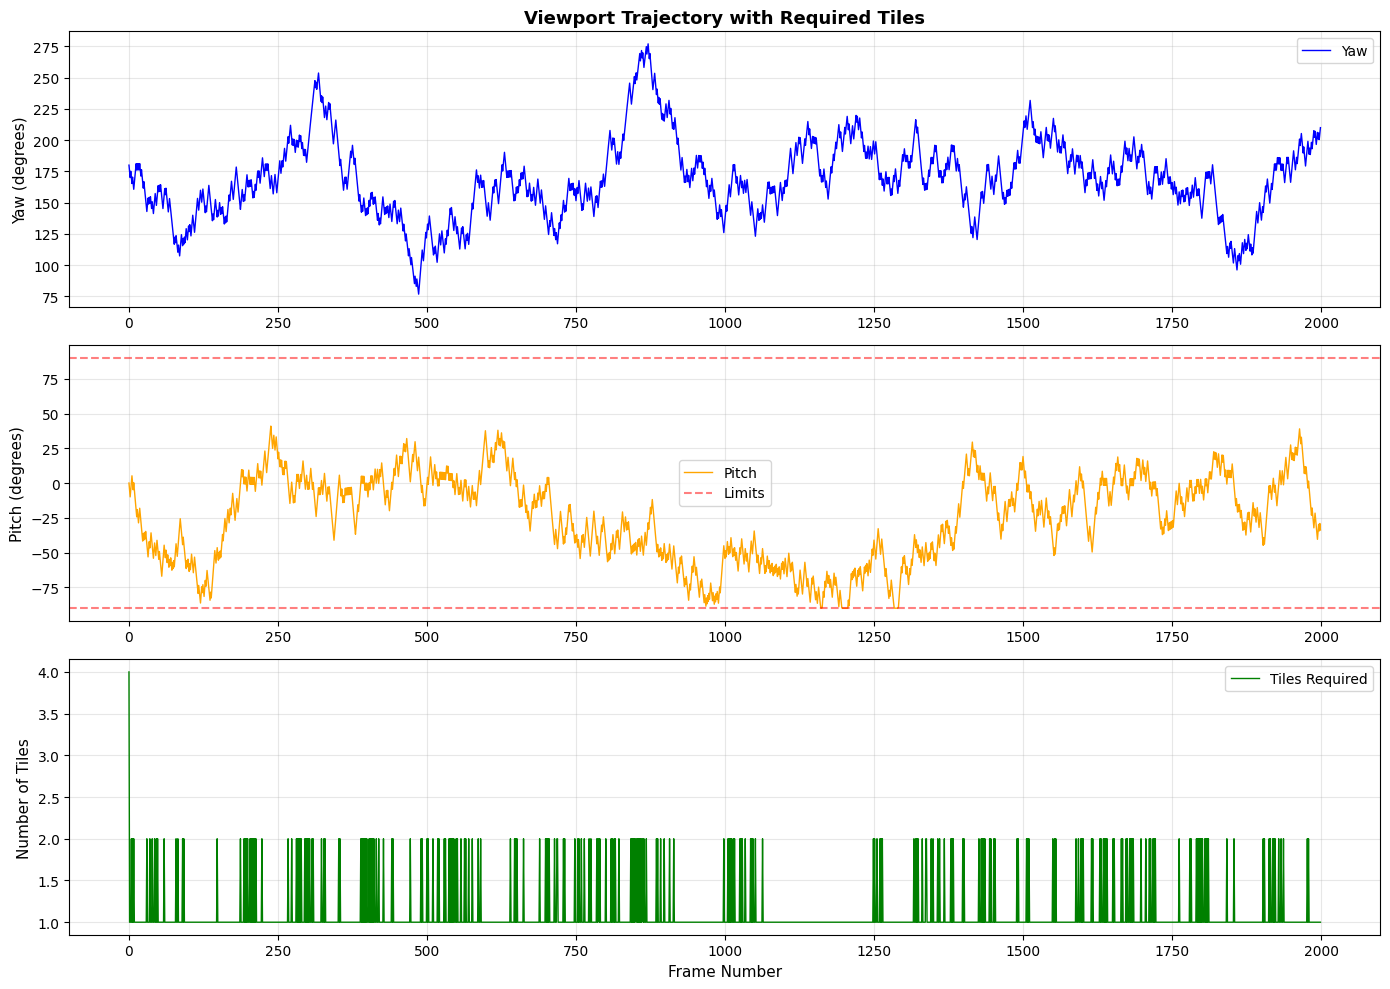


✓ Trajectory simulation complete with tile tracking!
  - yaw_trajectory shape: (2000,)
  - pitch_trajectory shape: (2000,)
  - tiles_array shape: (2000, 4)


In [ ]:
# ========================================
# Example: Run simulation and analyze tiles
# ========================================
if __name__ == '__main__':
    num_frames = 2000
    n_tiles = 4

    print("Simulating viewport trajectory with tile tracking...")
    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=num_frames,
        n=n_tiles,
        fov_yaw=90,
        fov_pitch=50,
        damping=0.99,
        step_size=5.0,
        start_yaw=180,
        start_pitch=0
    )

    print(f"\nSimulation complete!")
    print(f"Total frames: {num_frames}")
    print(f"Tile grid: {n_tiles}x{n_tiles} = {n_tiles**2} total tiles")
    print(f"Max tiles required in any frame: {tiles_array.shape[1]}")

    # Statistics
    tiles_per_frame_counts = [len(tiles) for tiles in tiles_per_frame]
    print(f"\nTile statistics:")
    print(f"  Min tiles per frame: {min(tiles_per_frame_counts)}")
    print(f"  Max tiles per frame: {max(tiles_per_frame_counts)}")
    print(f"  Avg tiles per frame: {np.mean(tiles_per_frame_counts):.2f}")

    # Show first 10 frames
    print(f"\nFirst 10 frames - required tiles (as linear indices):")
    for i in range(min(10, num_frames)):
        tiles_in_frame = tiles_array[i][tiles_array[i] != -1]
        print(f"  Frame {i:3d}: yaw={yaw[i]:6.2f}°, pitch={pitch[i]:6.2f}° → tiles: {tiles_in_frame}")

    # Count unique tiles accessed throughout entire trajectory
    all_tiles_accessed = set()
    for tiles_set in tiles_per_frame:
        for tile in tiles_set:
            all_tiles_accessed.add(tile[1] * n_tiles + tile[0])

    print(f"\nUnique tiles accessed: {len(all_tiles_accessed)} out of {n_tiles**2}")
    print(f"Coverage: {len(all_tiles_accessed) / (n_tiles**2) * 100:.1f}%")

    # Plot the trajectory with tile count overlay
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    # Yaw trajectory
    axes[0].plot(yaw, label='Yaw', color='blue', linewidth=1)
    axes[0].set_ylabel('Yaw (degrees)', fontsize=11)
    axes[0].set_title('Viewport Trajectory with Required Tiles', fontsize=13, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Pitch trajectory
    axes[1].plot(pitch, label='Pitch', color='orange', linewidth=1)
    axes[1].set_ylabel('Pitch (degrees)', fontsize=11)
    axes[1].axhline(y=90, color='red', linestyle='--', alpha=0.5, label='Limits')
    axes[1].axhline(y=-90, color='red', linestyle='--', alpha=0.5)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Number of tiles required per frame
    axes[2].plot(tiles_per_frame_counts, label='Tiles Required', color='green', linewidth=1)
    axes[2].set_ylabel('Number of Tiles', fontsize=11)
    axes[2].set_xlabel('Frame Number', fontsize=11)
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("\n✓ Trajectory simulation complete with tile tracking!")
    print(f"  - yaw_trajectory shape: {yaw.shape}")
    print(f"  - pitch_trajectory shape: {pitch.shape}")
    print(f"  - tiles_array shape: {tiles_array.shape}")

Visualizing trajectory sequence...


Frames 1400-1459 (60 frames):


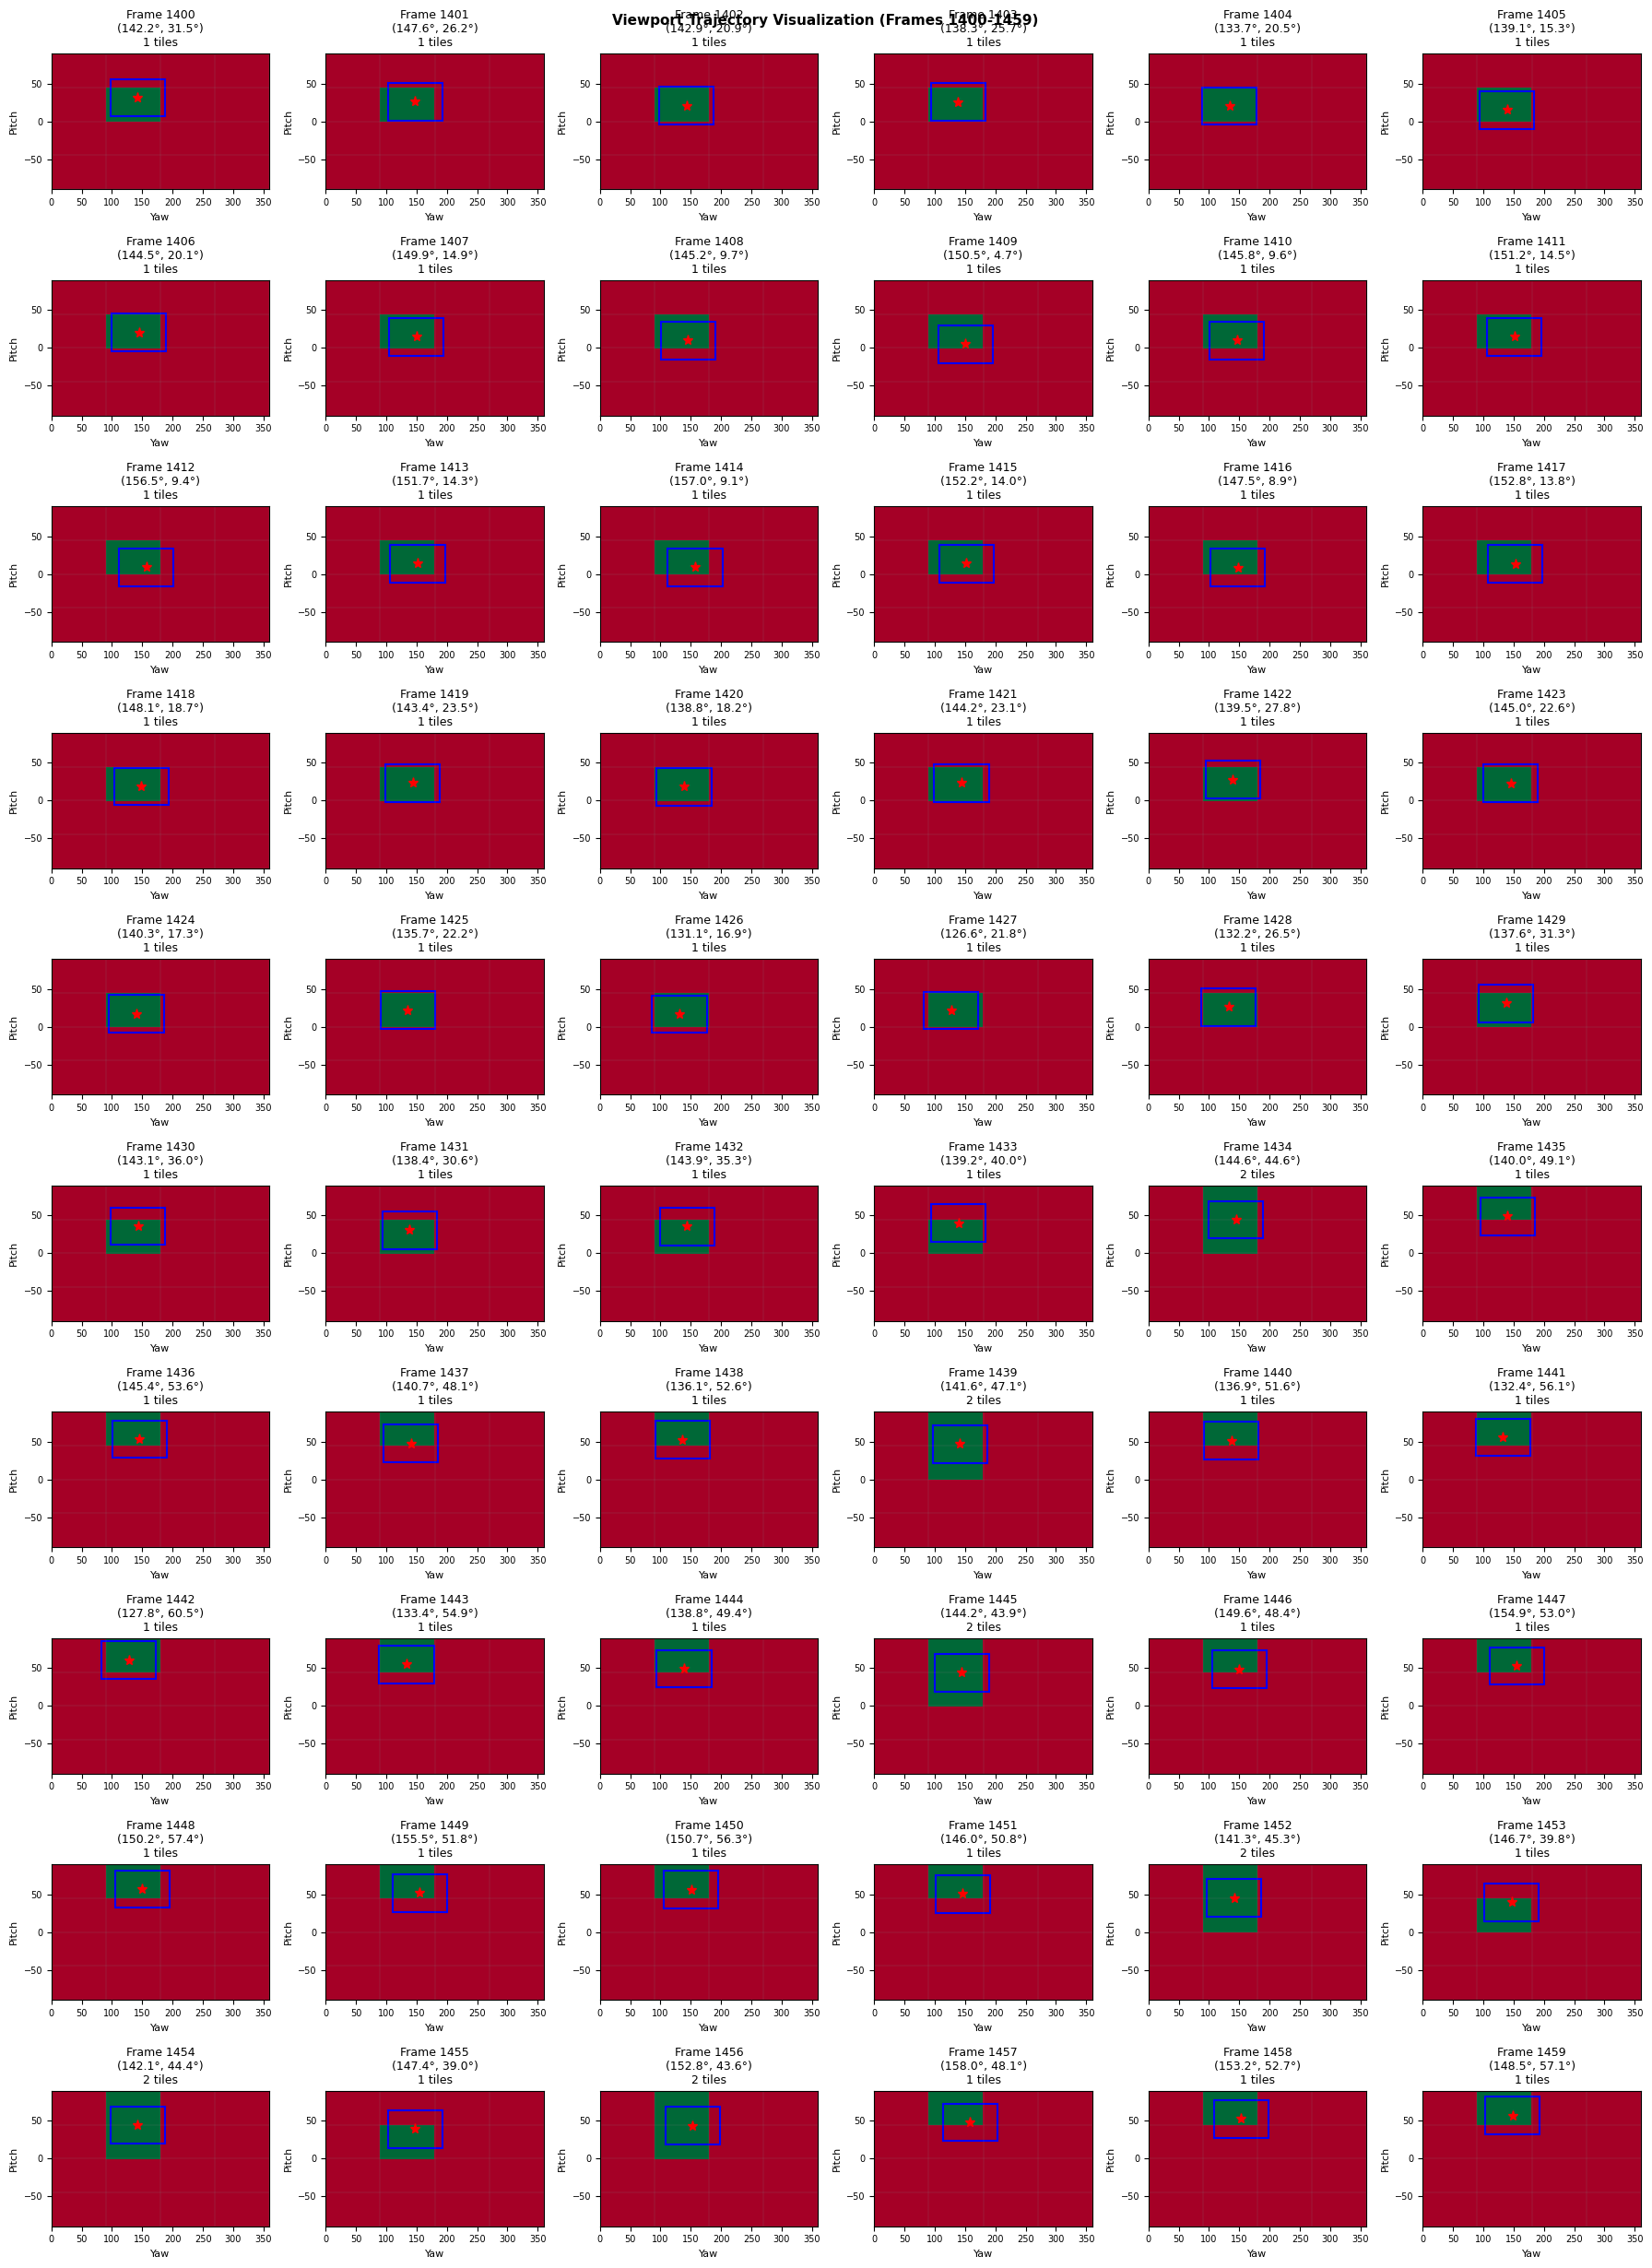

In [37]:
def visualize_trajectory_sequence(
    yaw, 
    pitch, 
    tiles_per_frame, 
    n=8, 
    fov_yaw=90, 
    fov_pitch=50,
    start_frame=0, 
    num_frames_to_show=6, 
    cols=3
):
    """
    Visualizes a sequence of frames from the trajectory showing viewport and required tiles.
    
    Parameters:
    - yaw: Array of yaw positions
    - pitch: Array of pitch positions
    - tiles_per_frame: List of sets containing required tiles
    - n: Grid size (8x8)
    - fov_yaw, fov_pitch: Field of view
    - start_frame: Which frame to start visualization from
    - num_frames_to_show: How many frames to display
    - cols: Number of columns in subplot grid
    """
    rows = int(np.ceil(num_frames_to_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = axes.flatten() if num_frames_to_show > 1 else [axes]
    
    for idx in range(num_frames_to_show):
        frame_num = start_frame + idx
        if frame_num >= len(yaw):
            axes[idx].axis('off')
            continue
            
        ax = axes[idx]
        
        # Get viewport parameters for this frame
        center_yaw = yaw[frame_num]
        center_pitch = pitch[frame_num]
        required_tiles = tiles_per_frame[frame_num]
        
        # Create tile grid
        tile_grid = np.zeros((n, n))
        
        # Mark required tiles
        for tile_x, tile_y in required_tiles:
            if 0 <= tile_x < n and 0 <= tile_y < n:
                tile_grid[tile_y, tile_x] = 1
        
        # Display the grid
        ax.imshow(
            tile_grid,  
            interpolation='nearest', 
            origin='lower',
            cmap='RdYlGn',
            extent=[0, 360, -90, 90], 
            aspect='auto', 
            vmin=0, 
            vmax=1
        )
        
        # Draw grid lines
        tile_size_yaw = 360 / n
        tile_size_pitch = 180 / n
        
        for i in range(n + 1):
            ax.axvline(
                i * tile_size_yaw, color='gray', linewidth=0.3, alpha=0.5
            )
            ax.axhline(
                -90 + i * tile_size_pitch, color='gray', linewidth=0.3, alpha=0.5
           )
        
        # Draw viewport FOV rectangle
        half_fov_yaw = fov_yaw / 2
        half_fov_pitch = fov_pitch / 2
        
        min_yaw = center_yaw - half_fov_yaw
        max_yaw = center_yaw + half_fov_yaw
        min_pitch = max(center_pitch - half_fov_pitch, -90)
        max_pitch = min(center_pitch + half_fov_pitch, 90)
        
        # Handle yaw wrapping
        if min_yaw < 0 or max_yaw > 360:
            if min_yaw < 0:
                ax.add_patch(plt.Rectangle(
                    (min_yaw + 360, min_pitch), 
                    -min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
            else:
                ax.add_patch(plt.Rectangle(
                    (min_yaw, min_pitch), 
                    360 - min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw - 360, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
        else:
            ax.add_patch(plt.Rectangle(
                (min_yaw, min_pitch), 
                fov_yaw, 
                max_pitch - min_pitch,
                fill=False, 
                edgecolor='blue', 
                linewidth=1.5
            ))
        
        # Mark center
        ax.plot(center_yaw, center_pitch, 'r*', markersize=8)
        
        # Set labels and limits
        ax.set_xlim(0, 360)
        ax.set_ylim(-90, 90)
        ax.set_title(f'Frame {frame_num}\n({center_yaw:.1f}°, {center_pitch:.1f}°)\n{len(required_tiles)} tiles',
                     fontsize=9)
        ax.set_xlabel('Yaw', fontsize=8)
        ax.set_ylabel('Pitch', fontsize=8)
        ax.tick_params(labelsize=7)
    
    # Hide any unused subplots
    for idx in range(num_frames_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Viewport Trajectory Visualization (Frames {start_frame}-{start_frame+num_frames_to_show-1})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ========================================
# Example: Visualize different parts of the trajectory
# ========================================
if __name__ == '__main__':
    num_frames = 2000
    n_tiles = 4

    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=num_frames,
        n=n_tiles,
        fov_yaw=90,
        fov_pitch=50,
        damping=0.99,
        step_size=5, # 1.5
        start_yaw=180,
        start_pitch=0
    )

    print("Visualizing trajectory sequence...\n")

    # # Show a longer sequence with more columns
    # print("\nFrames 950-1009 (60 frames):")
    # visualize_trajectory_sequence(
    #     yaw, 
    #     pitch, 
    #     tiles_per_frame, 
    #     n=n_tiles, 
    #     fov_yaw=120, 
    #     fov_pitch=60,
    #     start_frame=950, 
    #     num_frames_to_show=60, 
    #     cols=6
    # )

    # Show a longer sequence with more columns
    print("\nFrames 1400-1459 (60 frames):")
    visualize_trajectory_sequence(
        yaw, 
        pitch, 
        tiles_per_frame, 
        n=n_tiles, 
        fov_yaw=90, 
        fov_pitch=50,
        start_frame=1400, 
        num_frames_to_show=60, 
        cols=6
    )